# Mood-aware book recommender system EDA

## Project Overview
The goal of this project is to build a recommendation engine that suggests books based on a user's current mood. This notebook focuses on exploring the raw dataset to identify patterns, quality issues, and features that will eventually feed into our recommendation model. 

### EDA objectives
- Understand the structure, volume, and types of data available
- Identify missing values, duplicates, and logical inconsistencies
- Examine text features (descriptions, tags) and numerical distributions to plan future transformations. 
- Determine how ratings, popularity (ratings count), and book length correlate. 

---

In [41]:
import os
import math
import re
from collections import Counter
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv
import certifi
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect
import seaborn as sns

## Data Ingestion from MongoDB
Our raw data is hosted on a MongoDB Atlas cluster. We utilise `pymongo` to interface with the database and `pandas` for analytical manipulation. 

**Steps:**
- Load environment variables for secure access. 
- Establish a connection via `MongoClient`.
- Fetch all documents from the `books` collection and flatten them into a DataFrame.

In [ ]:
# Load in the credentials
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

# Connect to the MongoDB database
client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
db = client["BookProject"]
collection = db["books"]

# Convert the collection to a Pandas DataFrame
df = pd.DataFrame(list(collection.find()))

# Preview the first 5 rows
df.head()

,_id,book_id,title,description,average_rating,num_pages,ratings_count,publication_year,url,image_url,authors,tags
0,69ce925c11a85cb4bb15cf26,5333265,W.C. Fields: A Life on Film,,4.00,256,3,1984,https://www.goodreads.com/book/show/5333265-w-...,https://images.gr-assets.com/books/1310220028m...,[604031],"[to-read, p, collection, w-c-fields, biography]"
1,69ce925c11a85cb4bb15cf28,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,4.03,600,140,1987,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...,[10333],"[to-read, fantasy, fiction, owned, hardcover, ..."
2,69ce925c11a85cb4bb15cf2a,287140,Runic Astrology: Starcraft and Timekeeping in ...,,3.40,0,15,,https://www.goodreads.com/book/show/287140.Run...,https://images.gr-assets.com/books/1413219371m...,[149918],"[to-read, runes, owned, nonfiction, kill-it-wi..."
3,69ce925c11a85cb4bb15cf2e,34883016,Playmaker: A Venom Series Novella,Secrets. Sometimes keeping them in confidence ...,3.86,0,5,2017,https://www.goodreads.com/book/show/34883016-p...,https://images.gr-assets.com/books/1493525974m...,[5807700],"[to-read, ibooks, favorite-authors, may-2017-d..."
4,69ce925c11a85cb4bb15cf34,89373,The Bonfire of the Vanities,,3.82,0,77,,https://www.goodreads.com/book/show/89373.The_...,https://s.gr-assets.com/assets/nophoto/book/11...,[3083854],"[to-read, fiction, favorites, classics, curren..."


## Data Structure & Schema
Each of the rows of the dataset represents a book, and the data associated with it. Before we dig into what's stored in the dataset, we want to understand the scale and nature of the dataset:
- How many rows and columns? 
- What are the column names and what do they represent?
- What data types are present? (numeric, categorical, text, datetime, nested/JSON)
- Are there nested structures or lists within columns that need unpacking?

In [ ]:
# Let's check how many rows there are in the dataframe
print(f"Number of rows in the dataframe: {len(df)}")

# Let's look at the column names and their data types
print("Column names and data types in the dataframe:")
print(df.dtypes)

Number of rows in the dataframe: 10000
Column names and data types in the dataframe:
_id                  object
book_id                 str
title                   str
description             str
average_rating      float64
num_pages             int64
ratings_count         int64
publication_year        str
url                     str
image_url               str
authors              object
tags                 object
dtype: object


### Initial Observations on Data Types: 
- **Identification:** `_id` and `book_id` serve as primary identifiers. 
- **Metadata:** `title`, `url` and `image_url` are standard descriptive strings.
- **Numerical:** `average_rating`, `num_pages` and `ratings_count` are correctly typed as numeric.
- **Type Correction Needed:** `publication_year` is currently a string and needs to be cast as a numeric type to allow for chronological analysis. 
- **Complex Types:** `authors` and `tags` contain list objects (nested data) which will require specific handling during the feature engineering phase. 

In [ ]:
# Convert publication_year to numeric, coercing errors to NaN
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce")

As expected, we have 10000 values in our dataframe, where each entry represents a book. In `ingest.py` we specified the features we wanted to upload from the JSON file to MongoDB. The column names are self-explanatory, and  most of them have expectable data-types (floats, integers and string-objects). However, it is a good idea to bring attention to several of the features in the dataframe: `_id`, `authors`, `tags`. `_id` is a unique identifier assigned by MongoDB to every single document. It has no statistical value for our task, so we can eventually drop it from our dataframe. `authors` is a Foreign Key which relates to an author database. The `tags` feature contains lists of shelves users have created to store lists of books.  These lists will need unpacking at some point. 

## 3. Missing Data
Data missingness can be **explicit** (NaN/Null) or **implicit** (empty strings, "unknown, or 0"). 

### Strategy for Handling:
- **Publication Year:** If missing, we will drop the rows. 
- **Description:** Since this is a mood-aware system, descriptions are critical. Records without descriptions may be unusable for NLP tasks. 
- **Tags:** Empty tags indicate a lack of user-categorisation, which might limit our ability to determine the "vibe" or the book. 

Let's start by identifying explcit missng values.

In [5]:
# Count explicit missing values (NaN / None / pd.NA) per column
missing_counts = df.isnull().sum()

# Percentage missing per column
missing_percentages = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages
}).sort_values(by="missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
publication_year,2658,26.58
_id,0,0.00
book_id,0,0.00
title,0,0.00
description,0,0.00
average_rating,0,0.00
num_pages,0,0.00
ratings_count,0,0.00
url,0,0.00
image_url,0,0.00


What this means is that for every book in the dataframe, there are entries for all the columns. However, this does not mean that every piece of information in the dataset is valid. As mentioned earlier, missing data might show up as empty lists/dictionaries, and invalid numeric data. The following cell will explore implicit missing values which contain placeholders such as "", "N/A", "None", "unknown". 

In [6]:
# Define placeholder missing values
string_missing_values = ["", "N/A", "None", "unknown"]

# Count occurrences per column
implicit_string_missing = {}

for col in df.select_dtypes(include="object").columns:
    implicit_string_missing[col] = df[col].isin(string_missing_values).sum()

pd.Series(implicit_string_missing).sort_values(ascending=False)

/var/folders/bw/8d4vtgx964z6c40gb7b5yjz00000gn/T/ipykernel_7324/984642273.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


description    1750
url               1
image_url         1
_id               0
book_id           0
title             0
authors           0
tags              0
dtype: int64

Many entries are missing information regarding the publication year, as well as the description associated with the book. We will have to drop these values when we start cleaning the dataset. Let's now have a look at empty lists and dictionaries. 

In [7]:
def count_empty_containers(column):
    return column.apply(lambda x: x == [] or x == {}).sum()

empty_container_counts = {}

for col in df.columns:
    if df[col].dtype == "object":
        empty_container_counts[col] = count_empty_containers(df[col])

pd.Series(empty_container_counts).sort_values(ascending=False)

tags       176
authors      1
_id          0
dtype: int64

## Data quality issues:
It's also crucial to look at suspicious or invalid. Examples of invalid data include:
- `publication_year` being negative or larger than the current year.
- `title` duplicates: same book, different ID. 
- `average_rating` being negative or larger than 5, since we are using a 5-star rating system. 
- `num_pages` or `ratings_count` being negative
- Inconsistent formatting: dates in different formats or text with mixed encodings.
- `description` duplicates 

In [8]:
# Now we can check for invalid publication years (e.g., negative values, future years)
current_year = pd.Timestamp.now().year
invalid_years = df[
    (df["publication_year"] < 1450) | (df["publication_year"] > current_year)
]["publication_year"]
print(f"Number of invalid publication years: {len(invalid_years)}")

Number of invalid publication years: 15


In [ ]:
# Let's check for duplicate entries based on the title, or whether the title is invalid 
duplicate_titles = df[df.duplicated(subset=["title"], keep=False)]
print(f"Number of duplicate titles: {len(duplicate_titles)}")

Number of duplicate titles: 158


We detected 158 duplicate titles. In the book industry, duplicates often occur because:
1. The same book is published in different formats (Hardcover vs. Kindle). 
2. Different editions or publishers for the same title. 
We will likely need to group these by `title` and keep the version of the book with the highest `ratings_count` to ensure data variety. 

In [ ]:
# We can check the average rating column for outliers ( ratings outside the 0-5 range)
out_of_range_ratings = df[(df["average_rating"] < 0) | (df["average_rating"] > 5)]
print(f"Number of out-of-range average ratings: {len(out_of_range_ratings)}")   

Number of out-of-range average ratings: 0


In [ ]:
# Check the number of pages for outliers
out_of_range_pages = df[(df["num_pages"] < 0)]
print(f"Number of out-of-range page counts: {len(out_of_range_pages)}")

Number of out-of-range page counts: 0


In [12]:
# Let's study the number of ratings in the dataset and check for outliers
out_of_range_ratings_count = df[(df["ratings_count"] < 0)]
print(f"Number of out-of-range ratings counts: {len(out_of_range_ratings_count)}")

Number of out-of-range ratings counts: 0


In [13]:
# We also want to check that the descriptions column is not extremely short. 
short_descriptions = df[df["description"].str.len() < 20]
print(f"Number of short descriptions: {len(short_descriptions)}")

Number of short descriptions: 1767


In [14]:
# Let's check for duplicates in the descriptions
duplicate_descriptions = df[df.duplicated(subset=["description"], keep=False)]
print(f"Number of duplicate descriptions: {len(duplicate_descriptions)}")

Number of duplicate descriptions: 1832


We will delete the duplicate titles, invalid publication years, short descriptions and keep the duplicate descriptions, as two books of the same series can have the same description. 

## Distributions
We now want to explore what the data actually is. To do this, we will need to deal with numerical and categorical features separately. Text features will be analysed separately. 

### Numerical features
These are the checks we will perform:
- What's the range (min/max) of each numeric column?
- What are the quartiles (25th, 50th/median, 75th percentile)
- Mean vs median - are they very different? (Signals skew)
- Is the distribution normal, skewed, bimodal, heavy-tailed?
- Plot histograms: what shape do you see?
- Are there natural clusters or gaps in the distribution?

In [15]:
# Range of each numeric column
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")


average_rating: min=0.0, max=5.0
num_pages: min=0, max=3520
ratings_count: min=0, max=416634
publication_year: min=10.0, max=2019.0


- The `average_rating` ranges from 0 to 5. A 0.0 rating likely indicates a book with no reviews rather than a "bad" book.
- `num_pages` has a maximum of 3520 (likely an omnibus or reference book) and a minimum of 0 (missing data).
- `ratings_count` shows high skewness, with some books having over 400,000 ratings while many have very few. This suggests we may need to use a log-scale for this feature in the model.

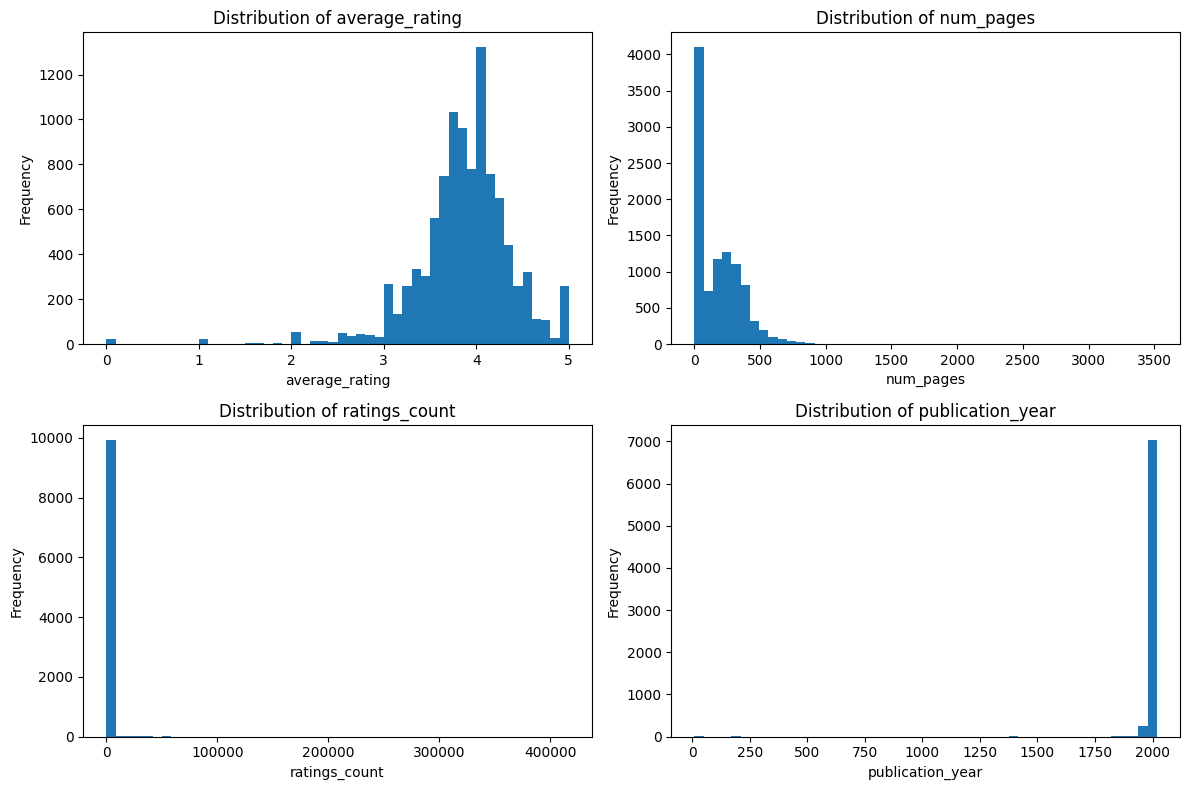

In [16]:
n_cols = 2  # number of columns in layout
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

axes = axes.flatten()  # makes indexing easier

for i, col in enumerate(numeric_columns):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(False)

# remove empty subplot spaces if odd number of plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

`average_rating` tells us that there is a positive bias in the book ratings. In a perfect world, we would have a curve centred around 2.5 or 3. This makes sense in reality, because people will only give ratings to books they have finished and therefore somewhat like. This means that the model will have a harder time telling apart a decent read from a masterpiece. 

`num_pages` is highly skewed to the left. Expectedly, most books have less than 1000 pages. We have a tiny amount of books in the 1000> range, which are outliers. We should not consider these books in our analysis, as books over 1000 pages are unlikely to be appealing to users. 

`ratings_count` tells us that most books have almost no ratings, and that a small amount of books have a large number of ratings (hence why the x-axis extends all the way to 400000). These books are not to be considered outliers, but rather an indication of what users genuinely enjoy, or have read. 

`publication_year` shows recency bias, since most books in the dataset have a publication year of 2000 onwards. 

This dataset represents a modern, well-liked collection of books. The recommendation engine shuold take the ratings tail into account, deciding whether to recommend trending books or focus on something a bit more niche. 

In [17]:
# Quartile summary of numeric columns
numeric_summary = df[numeric_columns].describe()
print(numeric_summary)

       average_rating     num_pages  ratings_count  publication_year
count    10000.000000  10000.000000   10000.000000       7342.000000
mean         3.864732    174.467500     360.583400       2004.416644
std          0.529259    187.852308    5199.494798         60.029792
min          0.000000      0.000000       0.000000         10.000000
25%          3.640000      0.000000       6.000000       2004.000000
50%          3.910000    152.000000      21.000000       2011.000000
75%          4.160000    289.000000      79.000000       2014.000000
max          5.000000   3520.000000  416634.000000       2019.000000


Let's compare the mean vs. the median for each numeric column. If they are very different, the signal is skewed. 

In [ ]:
# Compare the mean vs median for each numeric column to check for skewness
for col in numeric_columns:
    mean = df[col].mean()
    median = df[col].median()
    print(f"{col}: mean={mean}, median={median}")   

average_rating: mean=3.864731999999999, median=3.91
num_pages: mean=174.4675, median=152.0
ratings_count: mean=360.5834, median=21.0
publication_year: mean=2004.4166439662217, median=2011.0


### Categorical features
- How many unique values per categorical column?
- What's the frequency distribution? (value counts)
- Are categories balanced or imbalanced? (10000 romance, 5 westerns)
- High cardinality issues (10000+ unique authors - hard to encode)
- Typos/near-duplicates in categories? ("sci-fi" vs "scifi" vs "science-fiction")

In [19]:
df.dtypes

_id                  object
book_id                 str
title                   str
description             str
average_rating      float64
num_pages             int64
ratings_count         int64
publication_year    float64
url                     str
image_url               str
authors              object
tags                 object
dtype: object

In [20]:
# How many shelves per book?
df['tags'].apply(len).describe()


count    10000.000000
mean        55.474900
std         41.358238
min          0.000000
25%         12.000000
50%         53.000000
75%        100.000000
max        100.000000
Name: tags, dtype: float64

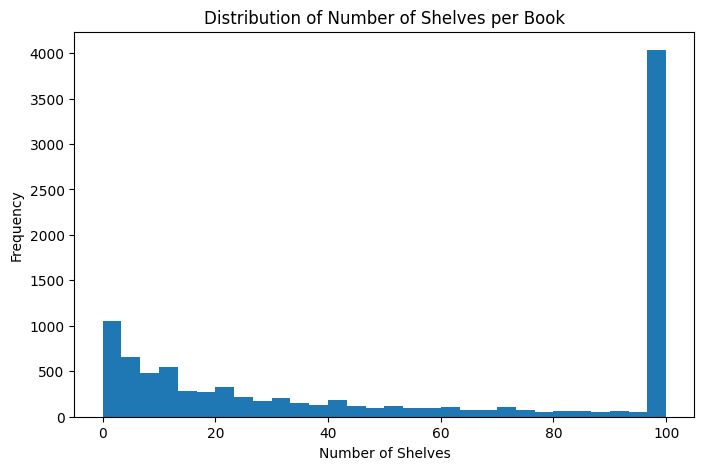

In [21]:

# Let's plot this distribution as well
plt.figure(figsize=(8, 5))
df['tags'].apply(len).hist(bins=30)
plt.title("Distribution of Number of Shelves per Book")
plt.xlabel("Number of Shelves")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()


We should study the correlation between number of shelves per book and the average rating of books

In [ ]:
# Let's study the correlation between number of shelves per book and average rating

# First, we create a feature that stores the number of shelves per book
df["num_shelves"] = df["tags"].apply(len)
# Now we can check the correlation between number of shelves and average rating
df[["num_shelves", "average_rating"]].corr()


,num_shelves,average_rating
num_shelves,1.000000,0.031259
average_rating,0.031259,1.000000


Luckily, there is almost no correlation between the average rating of a book and the number of shelves it has been saved to. We can now move on to see the most common shelf names across all books

In [23]:

# What are the most common shelf names across all books?
all_shelves = [shelf for shelves in df['tags'] for shelf in shelves]
Counter(all_shelves).most_common(50)


[('to-read', 9520),
 ('currently-reading', 7181),
 ('owned', 4655),
 ('fiction', 4385),
 ('favorites', 4343),
 ('books-i-own', 3902),
 ('kindle', 3740),
 ('ebook', 3391),
 ('library', 3267),
 ('default', 3265),
 ('owned-books', 2905),
 ('to-buy', 2763),
 ('ebooks', 2634),
 ('wish-list', 2536),
 ('romance', 2394),
 ('series', 2183),
 ('adult', 2128),
 ('contemporary', 2116),
 ('my-books', 2009),
 ('non-fiction', 1947),
 ('e-book', 1896),
 ('my-library', 1868),
 ('audiobook', 1825),
 ('books', 1812),
 ('fantasy', 1802),
 ('audiobooks', 1691),
 ('i-own', 1652),
 ('audio', 1610),
 ('mystery', 1606),
 ('novels', 1576),
 ('read-in-2016', 1562),
 ('favourites', 1542),
 ('read-in-2015', 1479),
 ('e-books', 1475),
 ('read-in-2017', 1433),
 ('nonfiction', 1408),
 ('history', 1307),
 ('young-adult', 1302),
 ('abandoned', 1263),
 ('maybe', 1260),
 ('novel', 1248),
 ('own-it', 1244),
 ('read-in-2014', 1242),
 ('historical', 1227),
 ('historical-fiction', 1217),
 ('adult-fiction', 1205),
 ('book-clu

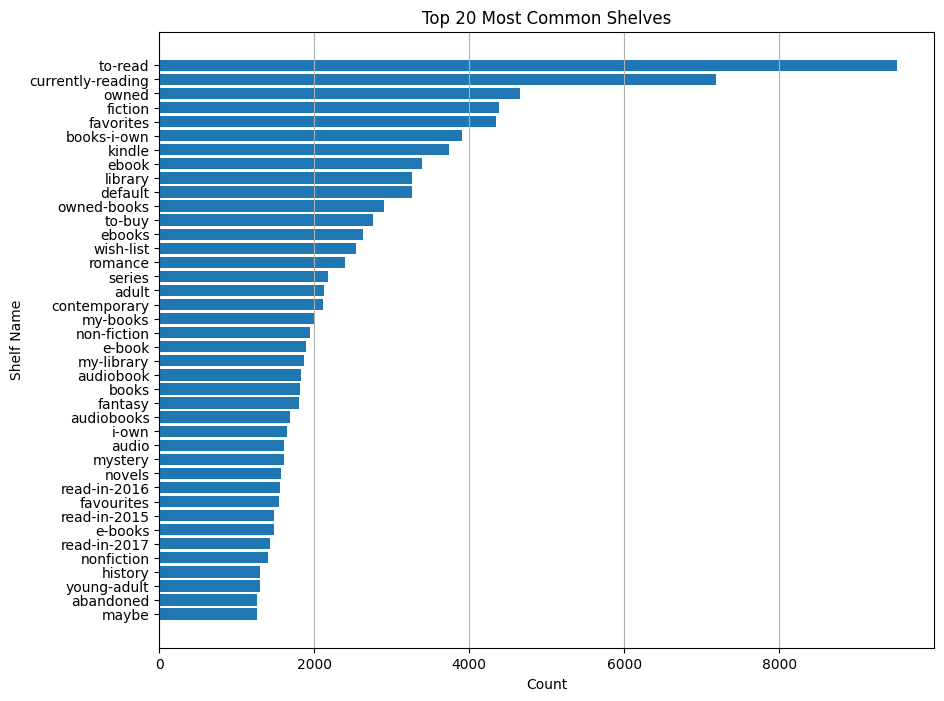

In [24]:
# Most common shelf names across all books
all_shelves = []
for tags_list in df['tags']:
    all_shelves.extend(tags_list)

# let's plot the distribution of the most common shelves
shelf_counts = Counter(all_shelves)
most_common_shelves = shelf_counts.most_common(40)
shelves, counts = zip(*most_common_shelves)
plt.figure(figsize=(10, 8))
plt.barh(shelves, counts)
plt.title("Top 20 Most Common Shelves")
plt.xlabel("Count")
plt.ylabel("Shelf Name")
plt.gca().invert_yaxis()  # invert y-axis to have the most common shelf at the top
plt.grid(axis='x')
plt.show()


The most common labels include information on whether the user has the book or doesn't, as well as the default shelves created by goodreads: to-read and currently-reading, so that the user can store the books they wish to read in the future. Many of the other tags include information about the book format such as `ebook`, and, as expected, many other tags include information about the genre of the book, as well as the language it is written in. Before we build the recommendation system, we wil have to filter out the tags that don't provide much information about the genre or mood the book is related to.

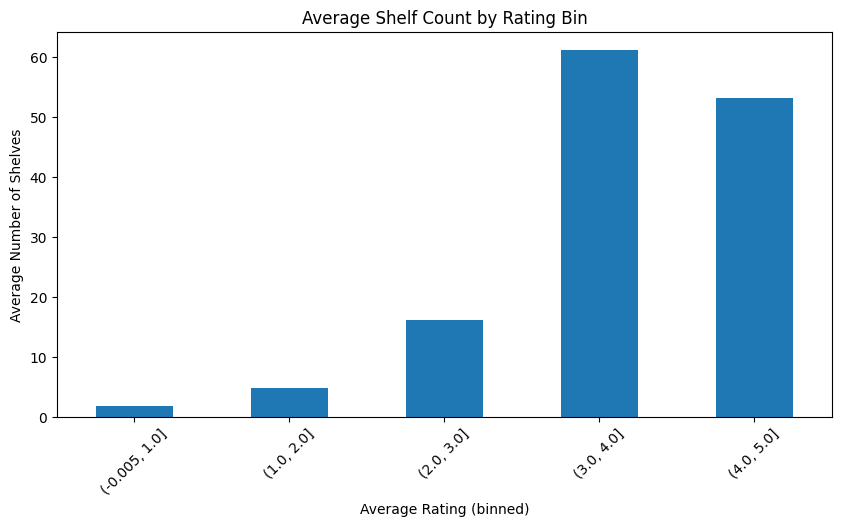

In [ ]:
# Let's look at how many shelves books with certain ratings have
df['num_shelves'] = df['tags'].apply(len)
df["rating_bin"] = pd.cut(df["average_rating"], bins=5)
avg_shelves_per_bin = df.groupby("rating_bin")["num_shelves"].mean()

avg_shelves_per_bin.plot(kind="bar", figsize=(10,5))

plt.xlabel("Average Rating (binned)")
plt.ylabel("Average Number of Shelves")
plt.title("Average Shelf Count by Rating Bin")

plt.xticks(rotation=45)
plt.grid(False)

plt.show()

Books with 3-5 stars have a lot more shelves than the other ones, which makes sense, since people will likely not shelf books they don't enjoy.

### DistributionsSummary
This concludes the [distributions](#distributions) section. In [numerical features](#numerical-features) we have identified that there is a positive bias in the book ratings. While this means that the model will have a harder time telling apart a good book from a truly great book, this can play in our favour. It implies that the model will recommend books with higher ratings, which is partially what we want: we do not want to recommend books which people generally don't enjoy.  

On the other hand, we should take care of outliers in the `num_pages` feature. It would also be a good idea to restrict the dataset to books that have been published semi-recently (i.e. 18th century onwards). 

In [categorical features](#categorical-features), we focused on the `tags` column in the dataset. We identified that we need to filter out tags related to book format, wish list, logistics, etc. This will be done in the data cleaning stage of the process. Additionally, we identified that books with 3-5 stars have more shelves thna others. This will not impact the data. 


## Text features
We will be studying the `descriptions` feature. Given that this is a text column, the EDA style changes a little bit here. We want to study whether this column is useful for a recommendation system. As mentioned in [missing data](#missing-data), there are some descriptions missing. These will be removed in the data cleaning stage of the project, as they provide no value to our predictions. 

The first thing we are going to do to study is whether all of the descriptions are in the same language, or whether there is variety in the dataset. This is very important because the machine learning model will determine two things are completely different based on text even though they are the same thing in different languages. 

We can use a Python module such as `langdetect` in order to determine which language it is written in. 

### Language detection

In [26]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

df['description_language'] = df['description'].apply(detect_language)

We can now check how many descriptions have been written in each language, which will tell us the dataset composition. 

In [27]:
df["description_language"].value_counts()

description_language
en         6596
unknown    1755
es          247
it          208
cy          158
id          138
fr          132
pt          122
de          120
nl           71
tr           58
fi           55
sv           35
sl           33
et           32
sk           32
pl           27
cs           26
ro           25
no           20
hr           16
so           14
da           14
hu           12
lt           12
tl           11
vi           11
lv            7
af            6
ca            5
sq            1
sw            1
Name: count, dtype: int64

There are many different languages in the dataset. However, luckily, most of the entries were written in english. To make the recommender system, we have to filter the data to only include the descriptions that are written in English. Otherwise, we can't extract meaningful information from our data. Note that there are some descriptions listed as "unknown". That is to be expected, since there are some strings which are empty, some may even be invalid. This was a great way for us to filter useful information from noise.

Now that we have identified this important issue with the data, we want to study the average length of the descriptions: depending on how many characters the book descriptions have, we will be able to extract meaningful information out of them, or not. Let's have a look. 

### Description length

In [28]:
df['description_length'] = df['description'].str.len()
df['description_length'].describe()

count    10000.000000
mean       698.203400
std        586.008114
min          0.000000
25%        244.000000
50%        647.500000
75%       1011.000000
max       6767.000000
Name: description_length, dtype: float64

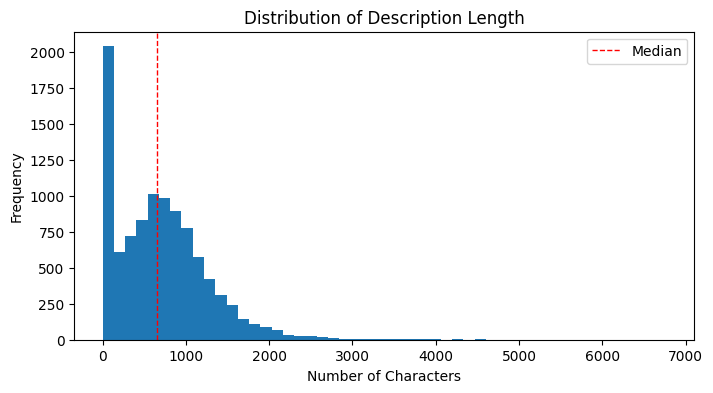

In [29]:
plt.figure(figsize=(8,4))
df["description_length"].hist(bins=50)

plt.title("Distribution of Description Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.grid(False)
plt.axvline(df['description'].str.len().median(), color='red', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.show()

In [30]:
df[["description_length", "average_rating"]].corr()

,description_length,average_rating
description_length,1.00000,0.05175
average_rating,0.05175,1.00000


Let's study the amount of words per description and whether there is correlation between the `average_rating` and the amount of words per description

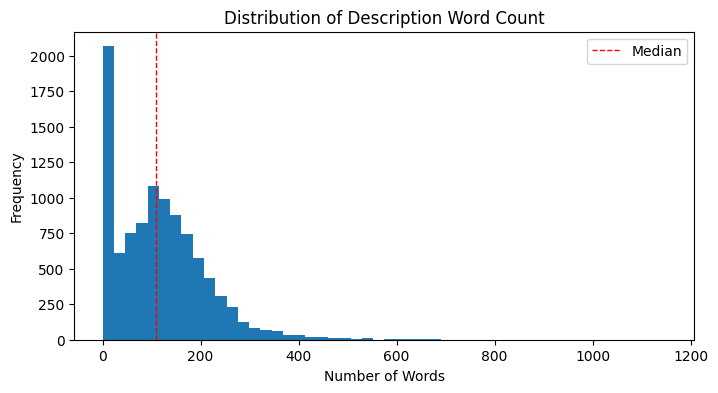

In [31]:
# Let's check how many words there are in each description
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

# Let's plot the number of words per description vs frequency in a histogram
plt.figure(figsize=(8,4))
df["description_word_count"].hist(bins=50)
plt.title("Distribution of Description Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.axvline(df['description_word_count'].median(), color='red', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.grid(False)
plt.show()

In [32]:
df["description_word_count"].describe()

count    10000.00000
mean       115.63390
std         97.29824
min          0.00000
25%         39.00000
50%        108.00000
75%        169.00000
max       1150.00000
Name: description_word_count, dtype: float64

In [33]:
# Let's check the correlation between description word count and average rating
# Although the correlation is likely to be the same as the one with description lenght
df[["description_word_count", "average_rating"]].corr()


,description_word_count,average_rating
description_word_count,1.000000,0.056963
average_rating,0.056963,1.000000


There are a lot of books with very few characters (under 500). If a description is only 10 words long, it is not very likely to add much information to the system. The good news is that most of the data is between 500 and 1000 characters (or 39-169 words), which is more than enough to extract a general "vibe" of what the book is about and/or feels like. 

On the other hand, there are also some descriptions with many characters/words, which may include reviews, short author biographies, etc. When we get to cleaning the dataset, we might want to truncate the descriptions, or remove the more extensive ones, as outliers. 

The correlation table above tells us that a long, detailed description does not automatically mean teh book is better (or that readers perceive it as better). A short blurb can be just as effective as a massive wall of text. This also means that this won't be a source of bias in the model: the model won't accidentally give higher scores to books just because they have more words. 

Some remaining questions for the text descriptions include:
- Is the text clean?
- Is the text consistent?
- Is the text informative?

We can start off by checking whether the descriptions contain HTML noise

### HTML noise

In [34]:
# Regex pattern for any HTML tag. 
html_pattern = re.compile(r'<.*?>')

# Function to check if a string has HTML. 
def has_html(text):
    if pd.isna(text):
        return False
    return bool(html_pattern.search(text))

# Apply this to the english descriptions and count how many have HTML tags
english_descriptions = df[df['description_language'] == 'en']['description']
english_descriptions_with_html = english_descriptions.apply(has_html).sum()
print(f"Number of English descriptions containing HTML tags: {english_descriptions_with_html}")


Number of English descriptions containing HTML tags: 5


We can also check for HTML entities:

In [35]:
#  Check for common HTML entities. 
entity_pattern = re.compile(r'&[a-zA-Z]+;', re.IGNORECASE)
entity_pattern = re.compile(r'&[a-z\d#]+;', re.IGNORECASE)

# Function to check for entities
def has_entities(text):
    if pd.isna(text):
        return False
    return bool(entity_pattern.search(str(text)))

# Apply to your existing 'english_descriptions' variable
english_descriptions_with_entities = english_descriptions.apply(has_entities).sum()

print(f"Number of English descriptions containing HTML entities: {english_descriptions_with_entities}")

Number of English descriptions containing HTML entities: 7


This concludes the EDA for descriptions. Most books contain sufficiently long English-language descriptions suitable for semantic embedding. Some HTML formatting noise is present and will be cleaned prior to modelling. 

## Relationships and Correlations
We analyse the correlation between numerical features to see if "longer books get better ratings" or if "popular books (high ratings count) tend to have higher averages".

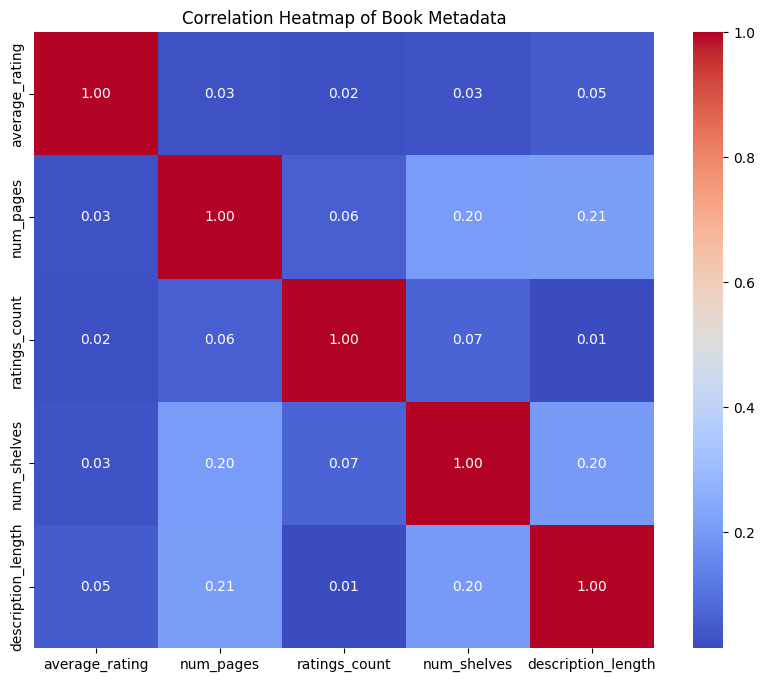

In [42]:

plt.figure(figsize=(10, 8))
# Select only relevant numerical columns
numeric_cols = ['average_rating', 'num_pages', 'ratings_count', 'num_shelves', 'description_length']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Book Metadata')
plt.show()

The correlation matrix confirms that the variables are independent of each other. We have now identified all necessary data cleaning and we can now move on. 

We have now successfully studied the dataset and identified key cleaning requirements. 
- Drop the records with missing or ultra-short descriptions. 
- Convert publication years and handle the 15 invalid entries found. 
- Handle duplicate book titles.
- Pre-process the `tags` list to extract genre and mood keywords. 